In [180]:
# Importing core libraries for data manipulation, visualization, 
import numpy as np  # Fundamental package for numerical operations on arrays
import pandas as pd  # Library for data manipulation and analysis using DataFrames

import matplotlib.pyplot as plt  # Plotting library for visualizing data
get_ipython().run_line_magic('matplotlib', 'inline')  # Enables inline plotting in Jupyter notebooks

import seaborn as sns  # High-level interface for statistical data visualization

from sklearn.model_selection import train_test_split  # Utility for splitting datasets into training and testing sets
from sklearn.preprocessing import StandardScaler  # Standardizes features by removing the mean and scaling to unit variance

In [181]:
youtube_data = pd.read_csv('Youtubers Data set.csv')

In [182]:
youtube_data.columns

Index(['Channel Name', 'Channel URL', 'Subscribers', 'Views', 'Category',
       'Country'],
      dtype='object')

In [183]:
youtube_data.head()

,Channel Name,Channel URL,Subscribers,Views,Category,Country
0,Narins Beauty,https://www.youtube.com/channel/UCWXYdNyGX01rn...,16000000,2573731771,beauty,US
1,Tah Beauty,https://www.youtube.com/channel/UCTtwNXEDNAuN-...,168000,16528740,beauty,US
2,Beauty,https://www.youtube.com/channel/UC12ZL54if5Q0q...,70000,22239847,beauty,US
3,Fenty Beauty By Rihanna,https://www.youtube.com/channel/UC0HVR9T6oFS3v...,1100000,240158508,beauty,US
4,BEAUTY NEWS,https://www.youtube.com/channel/UCvQgkrOiwcV9_...,489000,108906973,beauty,US


Channel Name: string
Channel URL: string
Subscribers: Continuous (Integer, e.g., 16,000,000)
Views: Continuous (Integer, e.g., 2,573,731,771)
Category: Categorical (e.g., beauty,education, technology)
Country: Categorical (e.g., US, IN, CA)

In [184]:
youtube_data.tail()

,Channel Name,Channel URL,Subscribers,Views,Category,Country
1340,AT Fashion with Tehsin Tahir,https://www.youtube.com/channel/UCmcRy5HXMXT7Z...,2650,237779,fashion,PK
1341,Well Made Fashion,https://www.youtube.com/channel/UCV9Dsc42Xq1Sn...,1630,143245,fashion,PK
1342,kanwal fashion designer,https://www.youtube.com/channel/UCQMHC26Tnnlnr...,33200,2981175,fashion,PK
1343,BR fashion,https://www.youtube.com/channel/UCzC4RjEntexyy...,154000,27716359,fashion,PK
1344,ST Fashion Hub,https://www.youtube.com/channel/UCGGugAlmr6S5m...,44300,9192756,fashion,PK


In [185]:
youtube_data.shape

(1345, 6)

1345 observations, 6 attributes, 5 are features and 1 is target

In [186]:
youtube_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1345 entries, 0 to 1344
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Channel Name  1345 non-null   object
 1   Channel URL   1345 non-null   object
 2   Subscribers   1345 non-null   int64 
 3   Views         1345 non-null   int64 
 4   Category      1345 non-null   object
 5   Country       1345 non-null   object
dtypes: int64(2), object(4)
memory usage: 63.2+ KB


The dataset contains 2 numerical features with integer values and 4 non-numerical features. There are no null values in the dataset

In [187]:
youtube_data.describe()

,Subscribers,Views
count,1.345000e+03,1.345000e+03
mean,1.661472e+06,4.802196e+08
std,6.046134e+06,1.742389e+09
min,0.000000e+00,0.000000e+00
25%,2.800000e+04,4.207033e+06
50%,2.290000e+05,4.052130e+07
75%,9.820000e+05,2.594608e+08
max,7.470000e+07,4.529805e+10


Subscribers range from 0 to 74.7 million, with an average of around 1.6 million
This indicates a wide variety of channel sizes—from very small to extremely popular channels

The median subscriber count is 229,000 while the upper quartile (75%) is at 982,000
Most channels have fewer than 982k subscribers with only a few large ones pushing the average upward

Views range from 0 to 45.2 billion, with a mean of 480 million views
This shows a high variation—some channels get very few views while others have massive audience reach

The median number of views is 40 million but the top 25% of channels have over 259 million views
Indicates a long-tail distribution where a few channels dominate total viewership

Both subscriber count and view count have very large standard deviations, confirming a high level of diversity in channel popularity

In [188]:
youtube_data['Category'].value_counts()

Category
music         180
fashion       156
beauty        147
technology    146
education     139
comedy        134
travel        128
gaming        119
food          106
sports         90
Name: count, dtype: int64

The dataset includes 10 different categories, with 'music' (180) being the most popular, followed by 'fashion' (156) and 'beauty' (147).

The least popular categories are 'sports' (90) and 'food' (106).

This distribution can be considered reasonably balanced, but there are noticeable differences in category sizes, with 'music' being the dominant category

This distribution can impact model training if we are trying to build a recommendation system or perform category prediction since the model may become biased towards the larger categories (like 'music')

To avoid this bias we consider techniques like resampling oversampling smaller categories or undersampling larger ones

Undersample Categories Larger than the Median:

Categories like 'music' (180), 'fashion' (156), and 'beauty' (147) would be undersampled to match a target count (like the median or another chosen value).

Oversample Categories Smaller than the Median:

Categories like 'sports' (90), 'food' (106), and 'gaming' (119) would be oversampled to match the same target count

Target Count: This can be the median of all category counts 134 

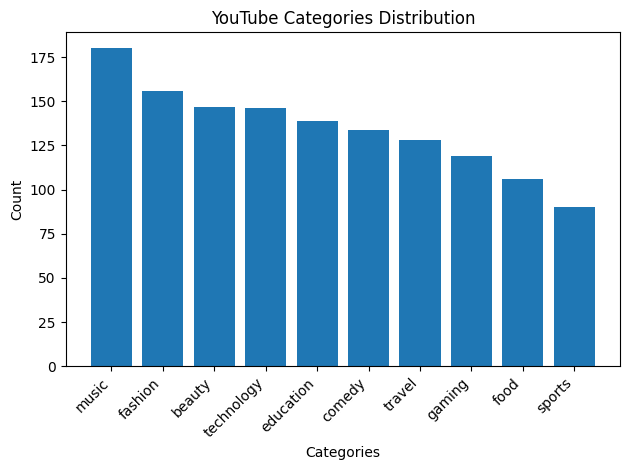

In [189]:
import matplotlib.pyplot as plt

# Counting category distribution
category_counts = youtube_data['Category'].value_counts()

# Creating the bar graph
plt.bar(category_counts.index, height=category_counts.values)
plt.title("YouTube Categories Distribution")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')  # Rotating for better visibility
plt.tight_layout()  # Adjust layout for better appearance
plt.show()


In [190]:
# Calculating average views per category
average_views_per_category = youtube_data.groupby('Category')['Views'].mean()
print(average_views_per_category)

Category
beauty        1.399481e+08
comedy        9.986475e+08
education     3.792058e+07
fashion       9.505961e+07
food          5.989293e+08
gaming        9.553676e+08
music         5.293308e+08
sports        1.411537e+09
technology    3.593588e+08
travel        1.519101e+08
Name: Views, dtype: float64


Categories like Sports, Comedy, and Gaming have much higher average views compared to Education and Beauty, which may indicate broader appeal for entertainment content.

The average views per category can guide content creators or advertisers in prioritizing where to invest their time or resources, based on the categories that drive the most engagement.

In [191]:
# Calculating average subscribers per category
average_subscribers_per_category = youtube_data.groupby('Category')['Subscribers'].mean()
print(average_subscribers_per_category)

Category
beauty        9.273768e+05
comedy        2.223192e+06
education     2.994274e+05
fashion       2.459482e+05
food          2.293980e+06
gaming        4.129913e+06
music         8.997164e+05
sports        5.582390e+06
technology    1.725460e+06
travel        5.434141e+05
Name: Subscribers, dtype: float64


Sports, Gaming, and Food are the categories with the highest average subscribers, highlighting their broad appeal and mass audience.

Beauty, Technology, and Comedy attract moderate but solid followings, catering to both niche and general audiences.

Education, Fashion, Entertainment and Travel are more niche categories, with smaller average subscriber counts. These types of channels often appeal to specific viewer interests but might not have the same mass appeal as entertainment and lifestyle content.

In [192]:
views_range = youtube_data.groupby('Category')['Views'].agg(['min', 'max'])
print(views_range)

                min          max
Category                        
beauty            0   2573731771
comedy         2943  14649228477
education      2201    842535279
fashion        1044   2260367125
food          48198   2892216027
gaming      2843122   8806608661
music             0  45298049048
sports            0   4732844147
technology    16374   8677504206
travel            0   2129046022


This will give us the range (minimum and maximum) of views in each category

In [193]:
subscriber_range = youtube_data.groupby('Category')['Subscribers'].agg(['min', 'max'])
print(subscriber_range)

              min       max
Category                   
beauty        237  16000000
comedy         26  21500000
education     154   2840000
fashion        20   3270000
food         1990  12600000
gaming       7570  47400000
music           0  65500000
sports      12900  74700000
technology    249  23700000
travel          0   5520000


This will give us the range (minimum and maximum) of Subscribers in each category

In [194]:
# Calculate correlation for numerical columns
correlation_matrix = youtube_data[['Views', 'Subscribers']].corr()

# Display the correlation matrix
print(correlation_matrix)

                Views  Subscribers
Views        1.000000     0.577212
Subscribers  0.577212     1.000000


Views ↔ Views (1.000000): The correlation of a feature with itself is always 1, indicating perfect positive correlation.

Subscribers ↔ Subscribers (1.000000): Similarly, the correlation of Subscribers with itself is also 1.

Views ↔ Subscribers (0.577212): This correlation suggests that channels with more views tend to have more subscribers as well, but the relationship is not perfect. While a channel with high views is likely to attract more subscribers, it's not guaranteed. Other factors (such as content quality, engagement, or marketing) might also play a role in increasing subscribers.

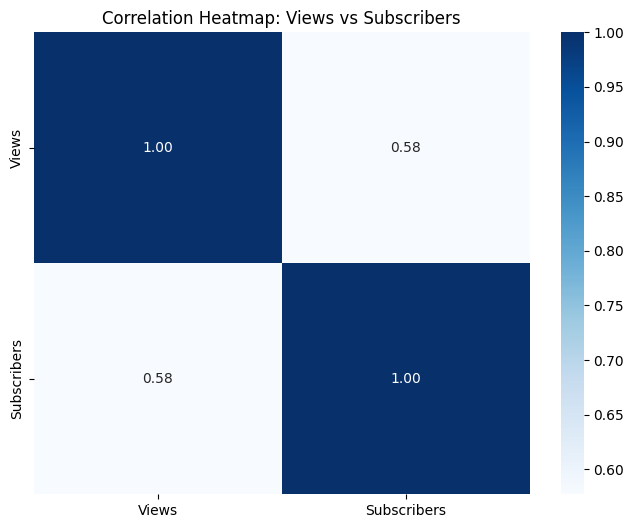

In [195]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the numerical features in your dataset
correlation_matrix = youtube_data[['Views', 'Subscribers']].corr()

# Visualize the correlation matrix using seaborn heatmap
plt.figure(figsize=(8, 6))  # Adjust the figure size for better visibility
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar=True, fmt='.2f')
plt.title('Correlation Heatmap: Views vs Subscribers')  # Title of the heatmap
plt.show()

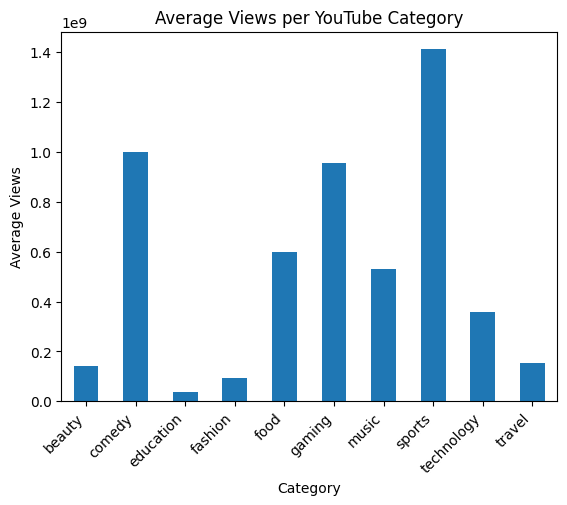

In [196]:
# Grouping by Category and calculating the average Views for each category
avg_views_per_category = youtube_data.groupby('Category')['Views'].mean()

# Plotting the bar chart
avg_views_per_category.plot(kind='bar')
plt.title('Average Views per YouTube Category')
plt.xlabel('Category')
plt.ylabel('Average Views')
plt.xticks(rotation=45, ha='right')
plt.show()

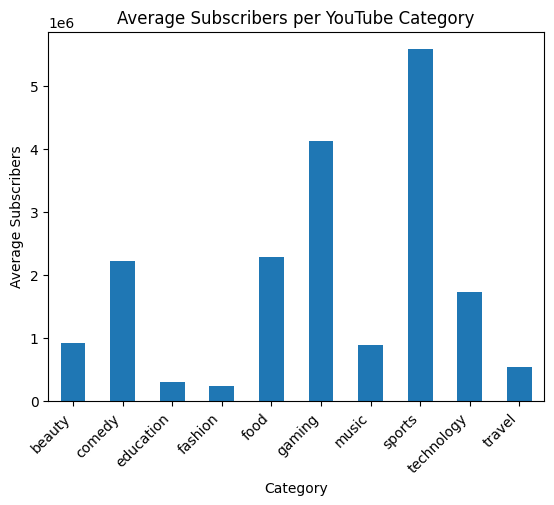

In [197]:
# Grouping by Category and calculating the average Subscribers for each category
avg_subscribers_per_category = youtube_data.groupby('Category')['Subscribers'].mean()

# Plotting the bar chart
avg_subscribers_per_category.plot(kind='bar')
plt.title('Average Subscribers per YouTube Category')
plt.xlabel('Category')
plt.ylabel('Average Subscribers')
plt.xticks(rotation=45, ha='right')
plt.show()

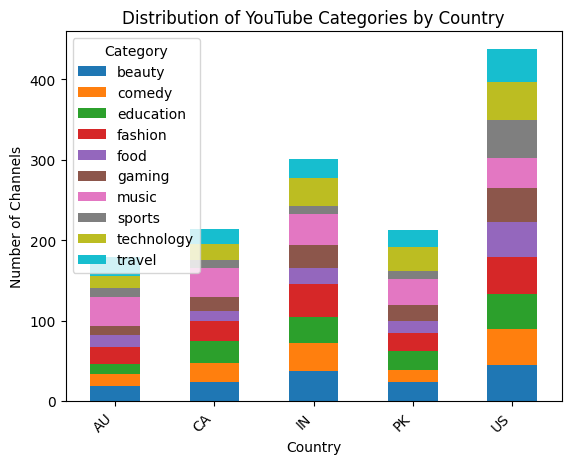

In [198]:
# Grouping by Country and Category to see the distribution
category_by_country = pd.crosstab(youtube_data['Country'], youtube_data['Category'])

# Plotting the bar chart
category_by_country.plot(kind='bar', stacked=True)
plt.title('Distribution of YouTube Categories by Country')
plt.xlabel('Country')
plt.ylabel('Number of Channels')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Category')
plt.show()

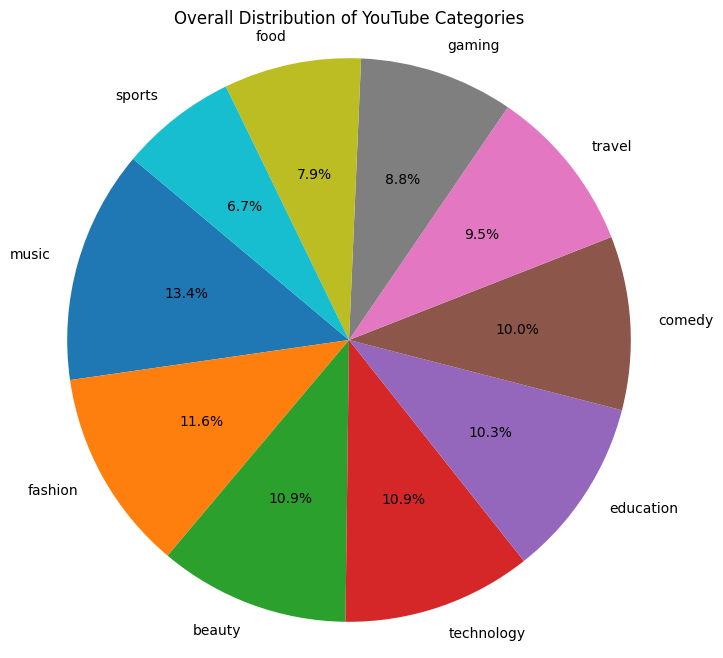

In [199]:
import pandas as pd
import matplotlib.pyplot as plt

# Category count across all countries
category_counts = youtube_data['Category'].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Overall Distribution of YouTube Categories')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Insights from the Pie Chart:

Music is the most popular YouTube category, accounting for 13.4% of all channels.

Fashion (11.6%), Beauty (10.9%), and Technology (10.9%) are also among the top categories 

Education (10.3%) and Comedy (10%) are also strong performers, indicating a high demand for both educational and entertaining content.

Travel (9.5%) and Gaming (8.8%) have slightly lower shares but still represent a significant portion of the content landscape.

Food (7.9%) and Sports (6.7%) have the smallest shares among the listed categories, though they still maintain a notable presence.

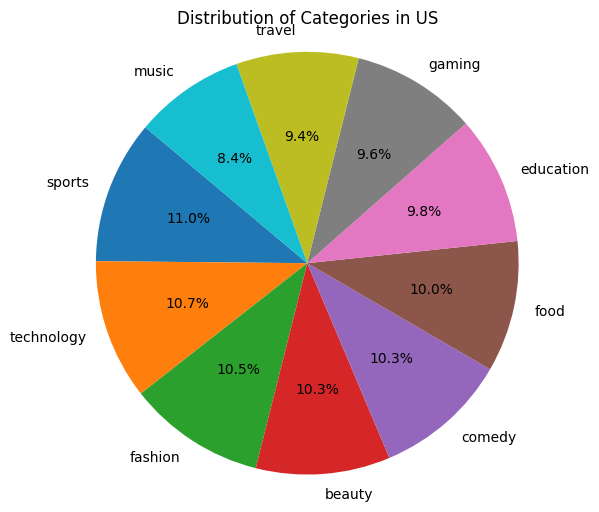

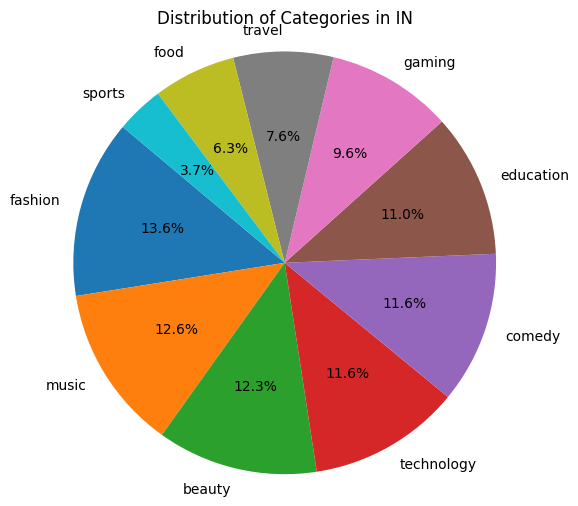

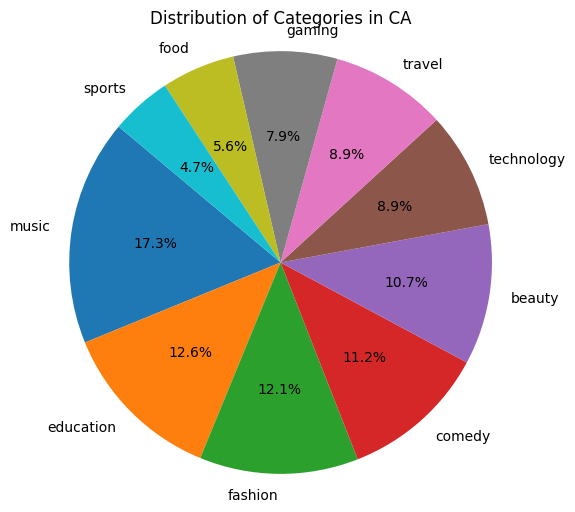

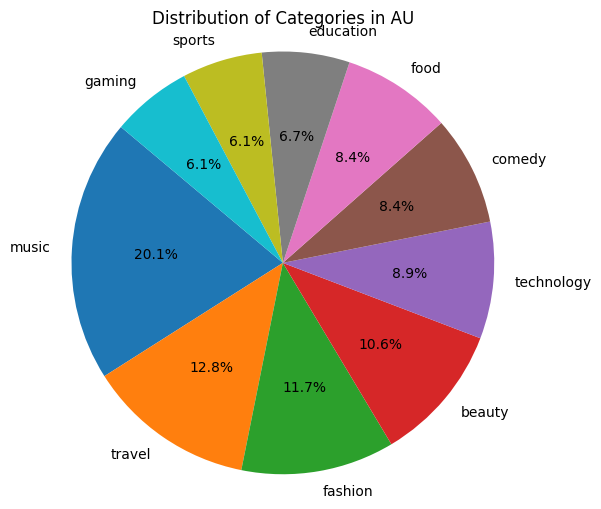

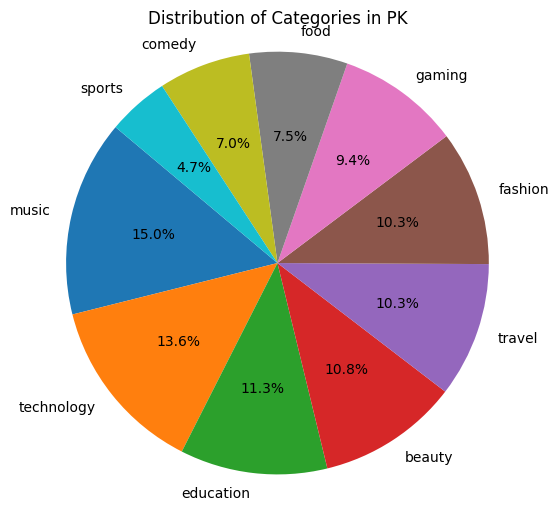

In [200]:
import pandas as pd
import matplotlib.pyplot as plt

# Grouping by country and category
countries = youtube_data['Country'].unique()

for country in countries:
    country_data = youtube_data[youtube_data['Country'] == country]
    category_counts = country_data['Category'].value_counts()

    plt.figure(figsize=(6, 6))
    plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=140)
    plt.title(f'Distribution of Categories in {country}')
    plt.axis('equal')
    plt.show()


**Insights:**
**🇺🇸 YouTube Category Insights – United States**
Sports is the leading category in the U.S. at 11.0%, highlighting Americans' strong interest in athletic content—ranging from game highlights and sports analysis to fitness and workout videos.
 Technology (10.7%), Fashion (10.5%), Beauty, and Comedy (10.3% each), along with Food (10.0%) follow closely behind, reflecting a well-rounded viewer interest across lifestyle, entertainment, and everyday practical topics.
 Education accounts for 9.8%, indicating a solid demand for informative and learning-oriented videos.
 Gaming (9.6%) and  Travel (9.4%) also retain notable viewer attention, showing consistent engagement with immersive and exploratory content.Music, while still relevant at 8.4%, ranks lowest among the major categories. This may suggest greater competition or fewer creators in this space compared to others.
 
 **CN Insights for Canada Chart:**
In Canada, music is the most dominant category at 17.3%, showing a clear national preference for audio-visual entertainment. Education (12.6%) and fashion (12.1%) also occupy large portions, reflecting a strong interest in knowledge-based and lifestyle content. Comedy makes up 11.2%, followed by beauty at 10.7%, showcasing a balance between humor and self-care content. Both technology and travel account for 8.9% each, suggesting a moderate interest in innovation and exploration. Gaming comes next at 7.9%, and the least represented categories are food (5.6%) and sports (4.7%), indicating comparatively lower audience engagement in these areas.
 
**🇮🇳 Insights for India Chart:**
In India, fashion leads with the highest share at 13.6%, suggesting a major audience interest in style and trends. Music follows closely at 12.6%, reinforcing its deep cultural presence. Beauty holds 12.3%, while technology and comedy are equally popular at 11.6% each, highlighting a strong demand for both personal care and entertaining content. Education captures 10.0%, indicating a solid engagement with learning material. Gaming represents 9.6%, pointing to the growing digital gaming trend. Other categories like travel (7.6%), food (6.3%), and sports (3.7%) round out the list, with sports showing the least representation, possibly due to a stronger preference for real-time viewing rather than online videos.


**In Australia**,Music (blue) is the leading category, making up 20.1% of content.Indicates music is the most consumed content in Australia.Travel (orange) holds the second-highest share at 12.8%.Suggests Australians have a strong interest in exploring places, travel vlogs, and destination reviews.
Fashion (green) follows with 11.7%. Shows that fashion content, including trends, styling tips, and hauls, attracts a large audience.Beauty (red) accounts for 10.6%.Reflects a healthy interest in skincare, makeup tutorials, and product reviews.Technology (purple) comes next with 8.9%.Indicates engagement with tech reviews, tutorials, and updates.Food and Comedy both have 8.4%.People enjoy culinary content and humorous videos equally.Education (gray) makes up 6.7%, showing demand for academic or informational content.Gaming (cyan) and Sports (yellow) each stand at 6.1%.These categories have dedicated but smaller audiences compared to the rest.


**In Pakistan**, Music (blue) makes up 15.0% of content.Indicates that music is a highly consumed and preferred category in Pakistan.Technology (orange) holds the second-highest share at 13.6%. Suggests strong interest in tech-related videos, such as reviews, unboxings, and tutorials.Education (green) accounts for 11.3%.Shows that educational content, including academic help and informational topics, is in demand.Beauty (red) makes up 10.8% of the content. Reflects a healthy engagement in beauty content such as makeup, skincare, and product reviews.Fashion (brown) stands at 10.3%.Indicates interest in style, clothing hauls, and fashion trends among viewers.Travel (purple) also holds 10.3%.Suggests viewers enjoy travel vlogs, location reviews, and adventure content.Gaming (pink) contributes 9.4%.Shows a solid fan base for gaming content, such as playthroughs, reviews, and live streams.Food (gray) makes up 7.5%.Highlights growing interest in culinary content, recipes, and food challenges.Comedy (dark gray) represents 7.0%.Indicates a good portion of viewers enjoy humorous, light-hearted content.Sports (light blue) is the smallest segment at 4.7%.Suggests that sports content has a more niche but dedicated audience.

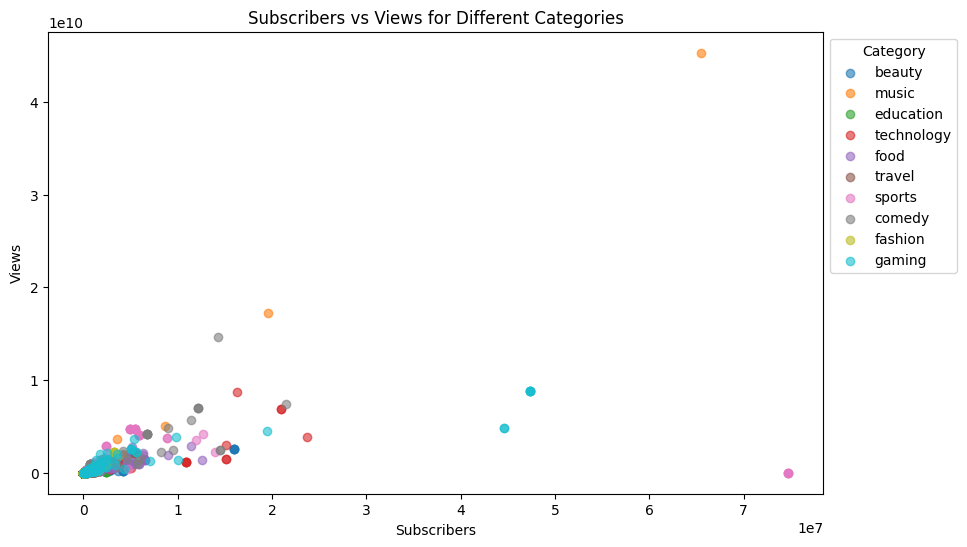

In [201]:
# Scatter plot to visualize the relationship between Subscribers and Views
plt.figure(figsize=(10, 6))
categories = youtube_data['Category'].unique()  # Get unique categories for coloring

for category in categories:
    subset = youtube_data[youtube_data['Category'] == category]
    plt.scatter(subset['Subscribers'], subset['Views'], label=category, alpha=0.6)

plt.xlabel("Subscribers")
plt.ylabel("Views")
plt.title("Subscribers vs Views for Different Categories")
plt.legend(title="Category", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()


This will help you see which categories tend to have more subscribers and views

In [144]:
# Count of each country in YouTube dataset (if you have a 'Country' column)
if 'Country' in youtube_data.columns:
    country_count = youtube_data["Country"].value_counts()
    print("Count of each country:\n", country_count)

Count of each country:
 Country
US    438
IN    301
CA    214
PK    213
AU    179
Name: count, dtype: int64


# MISSING VALUES 

In [202]:
# checking for missing values
youtube_data.isnull().sum()

Channel Name    0
Channel URL     0
Subscribers     0
Views           0
Category        0
Country         0
dtype: int64

There is no missing values in our dataset so we will not use any method to fill out missing values

# ENCODING

Using One-Hot Encoding because it avoids implying any ordinal relationship between categories,
which is important for models like Naive Bayes and KNN that are sensitive to numerical distances.
It also works well with Decision Tree and Random Forest.


Histograms help us understand the distribution of numeric features.
If the shape is bell-like, the data is approximately Gaussian (normal).
If the distribution is skewed (left or right), it indicates non-Gaussian data.

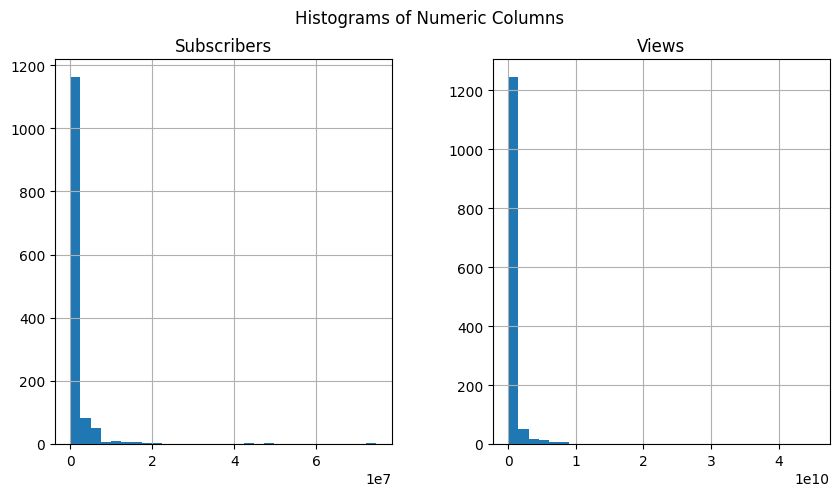

In [203]:
youtube_data.select_dtypes(include=[np.number]).hist(bins=30, figsize=(10,5))
plt.suptitle("Histograms of Numeric Columns")
plt.show()

The data is right skewed, indicating a non-Gaussian distribution

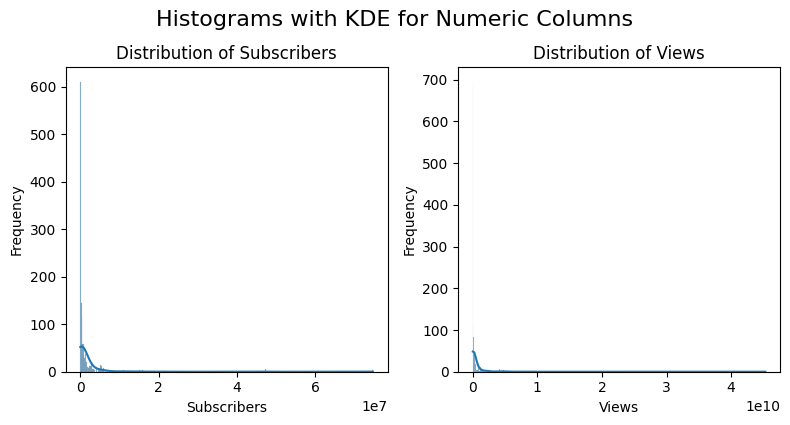

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Filter numeric columns from your DataFrame
numeric_cols = youtube_data.select_dtypes(include=[np.number]).columns

# Number of numeric columns
num_cols = len(numeric_cols)

# Define grid size (2 columns is enough for 2 plots)
ncols = 2
nrows = int(np.ceil(num_cols / ncols))

# Set figure size based on grid
plt.figure(figsize=(ncols * 4, nrows * 4))

# Loop through and plot each numeric column
for i, col in enumerate(numeric_cols):
    plt.subplot(nrows, ncols, i + 1)
    sns.histplot(youtube_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Histograms with KDE for Numeric Columns", fontsize=16, y=1.05)
plt.show()

The histograms show that the data is right skewed, this indicates that the distribution is not Gaussian (normal)

In [205]:
for col in ['Subscribers', 'Views']:
    Q1 = youtube_data[col].quantile(0.25)
    Q3 = youtube_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Outlier condition
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Show how many outliers
    outliers = youtube_data[(youtube_data[col] < lower_bound) | (youtube_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected.")

Subscribers: 191 outliers detected.
Views: 213 outliers detected.


Outliers were detected using the IQR method because our data is non-Gaussian (right skewed). The results are:
Subscribers: 191 outliers out of 1346 rows → ≈ 14.19%
Views: 213 outliers out of 1346 rows → ≈ 15.82%

Since more than 14–15% of the data points are outliers, and we are using sensitive models like KNN and Naive Bayes,
it is important to handle these outliers to avoid distorted results or reduced model performance.

In [206]:
# Numeric columns identify karo
numeric_features = youtube_data.select_dtypes(include=['number']).columns.tolist()

In [207]:
import numpy as np

for col in numeric_features:
    youtube_data[col] = np.log1p(youtube_data[col])

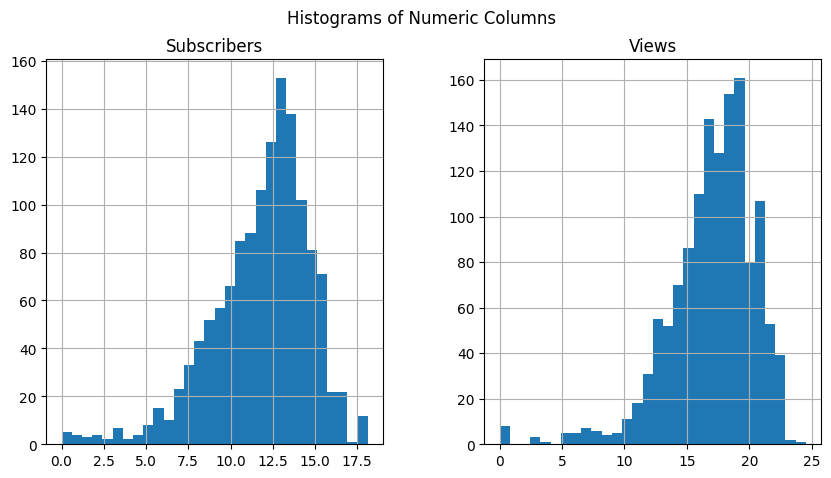

In [208]:
youtube_data.select_dtypes(include=[np.number]).hist(bins=30, figsize=(10,5))
plt.suptitle("Histograms of Numeric Columns")
plt.show()

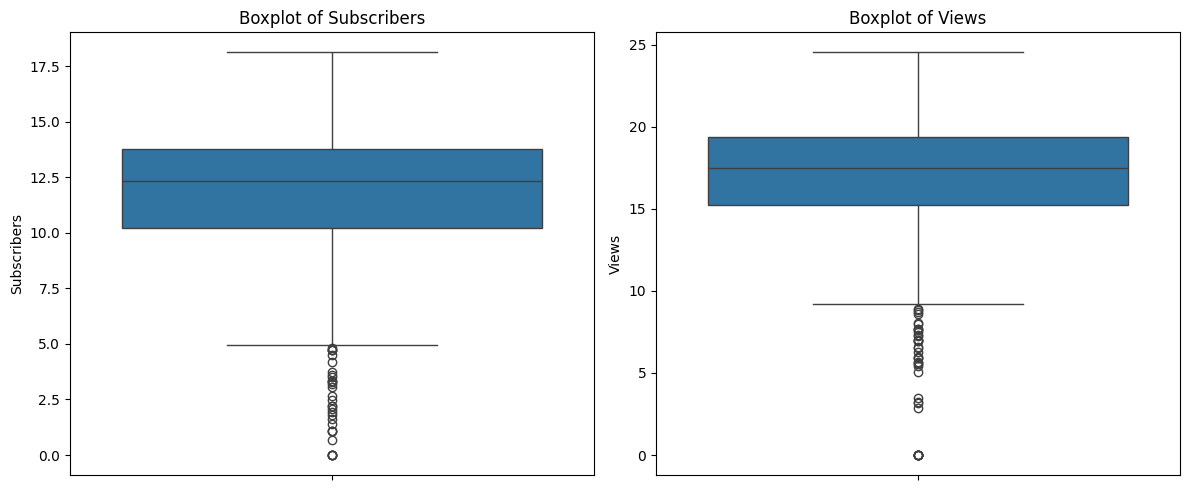

In [209]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Boxplot for Subscribers
plt.subplot(1, 2, 1)
sns.boxplot(data=youtube_data['Subscribers'])
plt.title('Boxplot of Subscribers')

# Boxplot for Views
plt.subplot(1, 2, 2)
sns.boxplot(data=youtube_data['Views'])
plt.title('Boxplot of Views')

plt.tight_layout()
plt.show()

y-axis range is 0 to 70 million subscribers
y-axis range is 0 to 40 billion views

# NORMALIZATION

**ROBUSTSCALER TO HANDLE OUTLIERS AND FEATURE SCALING**

we have used robustscalar because our data is heavily right skewed

In [210]:
# Function: Outliers remove karne ke liye — ek saath sab columns check karo
def remove_outliers_iqr_all_cols(data, columns):
    Q1 = youtube_data[columns].quantile(0.25)
    Q3 = youtube_data[columns].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Har column ke liye condition banaye: True agar value outlier nahi hai
    condition = ~((youtube_data[columns] < lower_bound) | (youtube_data[columns] > upper_bound)).any(axis=1)

    # Jo rows sab columns me outlier nahi hain unko select karo
    return youtube_data[condition]

# Outliers remove karo ek saath saare numeric columns ke liye
df_clean = remove_outliers_iqr_all_cols(youtube_data, numeric_features)

print(f"Original data rows: {youtube_data.shape[0]}")
print(f"Data after outliers removal: {df_clean.shape[0]}")

Original data rows: 1345
Data after outliers removal: 1300


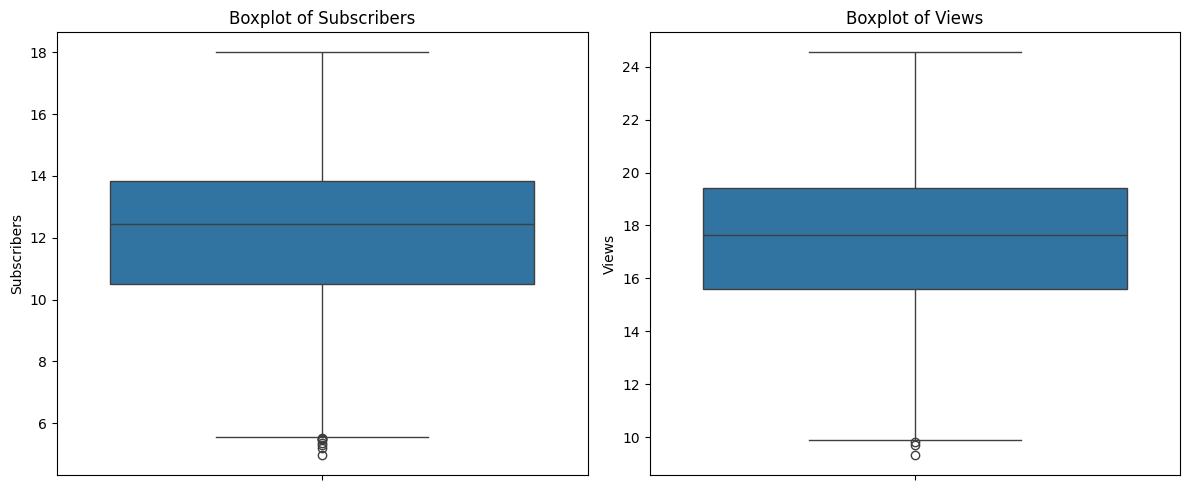

In [211]:
plt.figure(figsize=(12, 5))

# Boxplot for Subscribers
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean['Subscribers'])
plt.title('Boxplot of Subscribers')

# Boxplot for Views
plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean['Views'])
plt.title('Boxplot of Views')

plt.tight_layout()
plt.show()

In [212]:
from sklearn.preprocessing import RobustScaler
# RobustScaler se scale karo
scaler = RobustScaler()
scaled_values = scaler.fit_transform(df_clean[numeric_features])
scaled_robust_df = pd.DataFrame(scaled_values, columns=numeric_features)

# Non numeric columns le lo
non_numeric_df = df_clean.drop(columns=numeric_features).reset_index(drop=True)

# Combine scaled numeric and non-numeric columns
final_df = pd.concat([non_numeric_df, scaled_robust_df.reset_index(drop=True)], axis=1)

# Save to new CSV
final_df.to_csv('Youtubers_Data_RobustScaled_Cleaned.csv', index=False)

print("Outliers removed (all columns simultaneously) and data scaled. File saved.")

Outliers removed (all columns simultaneously) and data scaled. File saved.


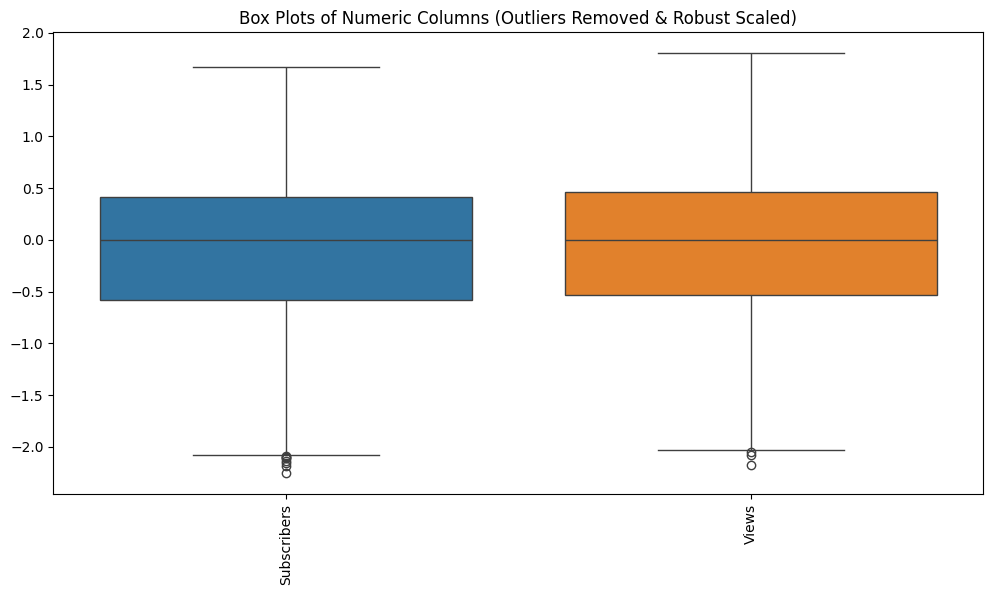

In [213]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=final_df.select_dtypes(include=[np.number]))
plt.title("Box Plots of Numeric Columns (Outliers Removed & Robust Scaled)")
plt.xticks(rotation=90)
plt.show()

In [214]:
#median - all colomns
print("First 5 rows of scaled numeric data:")
print(scaled_robust_df.head())

First 5 rows of scaled numeric data:
   Subscribers     Views
0     1.248963  1.052232
1    -0.125267 -0.269259
2    -0.389311 -0.191565
3     0.441480  0.431328
4     0.196967  0.224308


**Feature Reduction**:
we have done coorelation above in data understaning.
now
    PCA transforms original features into new combined components, which makes 
    it hard to understand the meaning of each feature, knowing real features like Subscribers and Views 
    is important, so PCA can confuse the model and reduce interpretability.

**FEATURE SELECTION**

In [215]:
from sklearn.feature_selection import SelectKBest, f_classif
# Only numeric features
X = final_df[['Subscribers', 'Views']]     # 2 numerical columns
y = final_df['Category']                   # Categorical target
# Select both features using ANOVA
selector = SelectKBest(score_func=f_classif, k=1)
X_new = selector.fit_transform(X, y)
# Get selected columns
selected_features = selector.get_support(indices=True)
selected_columns = X.columns[selected_features]
# New DataFrame with selected features
selected_df = final_df[selected_columns]
print("Selected Features:", selected_columns.tolist())
print(selected_df.head())

Selected Features: ['Views']
      Views
0  1.052232
1 -0.269259
2 -0.191565
3  0.431328
4  0.224308


we have done ANOVA with our clean_df because it helps to identify which original features have a significant effect on 
the target category. It keeps features understandable and directly shows their importance.
we have 2 numerical features(subscribers,views) so, to get the important feature with category we have assigned k=1

In [216]:
print(selector.scores_)

[41.23709091 55.34234898]


Feature	    ANOVA_F-score	  Meaning
Subscribers	11.34	          Has some effect on the target (Category)
Views	    27.72             Has a stronger effect on the target (Category) 
this is showing that views is more important feature to us for our target (category)

In [217]:
final_df.head()

,Channel Name,Channel URL,Category,Country,Subscribers,Views
0,Narins Beauty,https://www.youtube.com/channel/UCWXYdNyGX01rn...,beauty,US,1.248963,1.052232
1,Tah Beauty,https://www.youtube.com/channel/UCTtwNXEDNAuN-...,beauty,US,-0.125267,-0.269259
2,Beauty,https://www.youtube.com/channel/UC12ZL54if5Q0q...,beauty,US,-0.389311,-0.191565
3,Fenty Beauty By Rihanna,https://www.youtube.com/channel/UC0HVR9T6oFS3v...,beauty,US,0.441480,0.431328
4,BEAUTY NEWS,https://www.youtube.com/channel/UCvQgkrOiwcV9_...,beauty,US,0.196967,0.224308


In [218]:
final_df = final_df.drop(['Channel URL', 'Channel Name'], axis=1)
#axis=0 → Row
#Matlab: row number ya index based row ko hatao axis=1 → Column
#Matlab: column ke naam se column hatao

we have dropped the col Channel URL and Channel Name because for model training we want catogorical 
colomns with label encoding since both of them are in text form so for training 
the model we have to drop them

In [219]:
final_df.head()

,Category,Country,Subscribers,Views
0,beauty,US,1.248963,1.052232
1,beauty,US,-0.125267,-0.269259
2,beauty,US,-0.389311,-0.191565
3,beauty,US,0.441480,0.431328
4,beauty,US,0.196967,0.224308


**class balance and resampling**

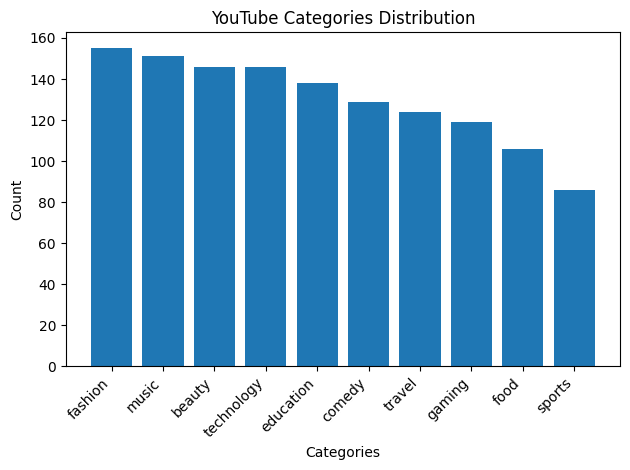

In [220]:
import matplotlib.pyplot as plt

# Counting category distribution
category_counts = final_df['Category'].value_counts()

# Creating the bar graph
plt.bar(category_counts.index, height=category_counts.values)
plt.title("YouTube Categories Distribution")
plt.xlabel("Categories")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')  # Rotating for better visibility
plt.tight_layout()  # Adjust layout for better appearance
plt.show()

In [221]:
final_df['Category'].value_counts()

Category
fashion       155
music         151
beauty        146
technology    146
education     138
comedy        129
travel        124
gaming        119
food          106
sports         86
Name: count, dtype: int64

Here,we can say that music(180) and sports(90) so, we have 50% imbalanced dataset which we can say is
Relatively Balanced Dataset because the difference is small enough not to severely impact model performance.As,
Rule of thumb: If no class is less than ~40% or more than ~60%, it's usually acceptable.
so, there is no need of oversampling and undersampling

**MODEL SELECTION**

we will be choosing  models for classification as our target colomn "category" is catagorical .
for this we will be using the following models:
Knn,Naivebayes,Decisiontree,Randomforest

Splitting our roburstScaled data into x,y and then xtrain,ytrain,xtest,ytest

In [222]:
print(final_df['Category'].unique())

['beauty' 'music' 'education' 'technology' 'food' 'travel' 'sports'
 'comedy' 'fashion' 'gaming']


In [223]:
# ✅ Step: Simplify target categories
def simplify_category(cat):
    Original=cat
    cat = str(cat).strip().lower()
    if cat in ['fashion', 'beauty', 'travel', 'food']:
        return 'Lifestyle'
    elif cat in ['music', 'gaming', 'sports', 'comedy']:
        return 'Entertainment'
    elif cat in ['technology', 'education']:
        return 'Education'
    else:
        return 'Other'

final_df['Category'] = final_df['Category'].apply(simplify_category)

# Optional: check balance
print(final_df['Category'].value_counts(normalize=True))

Category
Lifestyle        0.408462
Entertainment    0.373077
Education        0.218462
Name: proportion, dtype: float64


In [224]:
final_df.head()

,Category,Country,Subscribers,Views
0,Lifestyle,US,1.248963,1.052232
1,Lifestyle,US,-0.125267,-0.269259
2,Lifestyle,US,-0.389311,-0.191565
3,Lifestyle,US,0.441480,0.431328
4,Lifestyle,US,0.196967,0.224308


In [227]:
from sklearn.preprocessing import LabelEncoder

le_category = LabelEncoder()
le_country = LabelEncoder()

final_df['Category'] = le_category.fit_transform(final_df['Category'])
final_df['Country'] = le_country.fit_transform(final_df['Country'])

In [228]:
# Features aur target label split karo
X = final_df.drop('Category', axis=1)
y = final_df['Category']

test_size=0.2 for 80% train and 20% test sets

In [229]:
from sklearn.model_selection import train_test_split
# Train aur test data split kar rahe hain
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Dekho shapes ya size
print("X_train size:", X_train.shape)
print("X_test size:", X_test.shape)

X_train size: (1040, 3)
X_test size: (260, 3)



🔍 Training KNN...
 KNN Accuracy: 0.4846


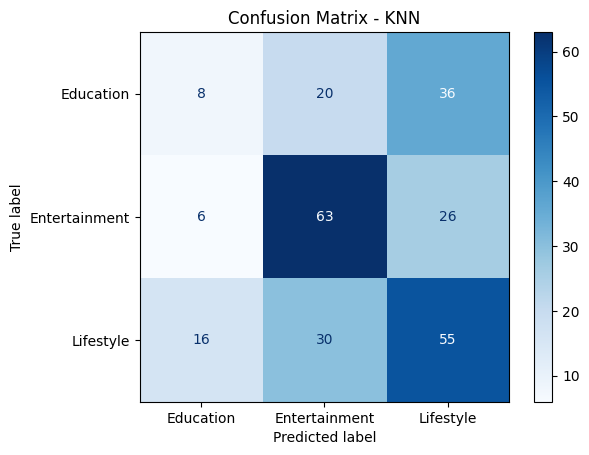

 Classification Report:
               precision    recall  f1-score   support

    Education       0.27      0.12      0.17        64
Entertainment       0.56      0.66      0.61        95
    Lifestyle       0.47      0.54      0.50       101

     accuracy                           0.48       260
    macro avg       0.43      0.44      0.43       260
 weighted avg       0.45      0.48      0.46       260


🔍 Training Decision Tree...
 Decision Tree Accuracy: 0.5192


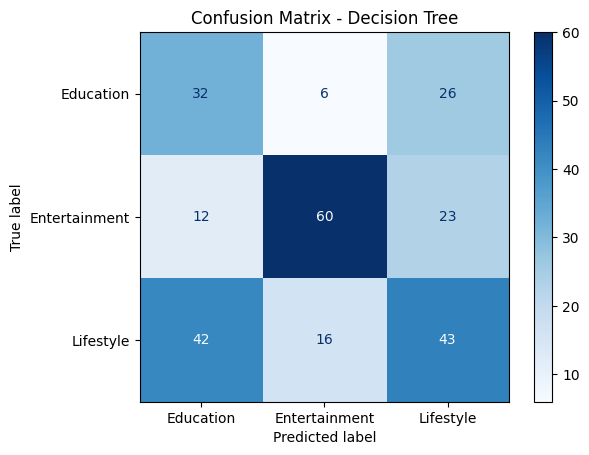

 Classification Report:
               precision    recall  f1-score   support

    Education       0.37      0.50      0.43        64
Entertainment       0.73      0.63      0.68        95
    Lifestyle       0.47      0.43      0.45       101

     accuracy                           0.52       260
    macro avg       0.52      0.52      0.52       260
 weighted avg       0.54      0.52      0.53       260


🔍 Training Naive Bayes...
 Naive Bayes Accuracy: 0.5192


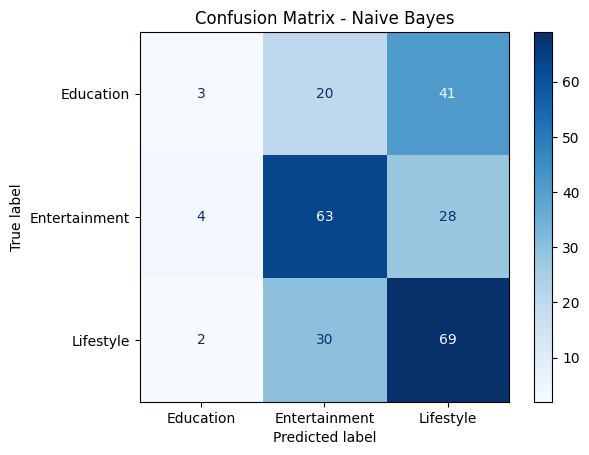

 Classification Report:
               precision    recall  f1-score   support

    Education       0.33      0.05      0.08        64
Entertainment       0.56      0.66      0.61        95
    Lifestyle       0.50      0.68      0.58       101

     accuracy                           0.52       260
    macro avg       0.46      0.46      0.42       260
 weighted avg       0.48      0.52      0.47       260


🔍 Training Random Forest...
 Random Forest Accuracy: 0.4769


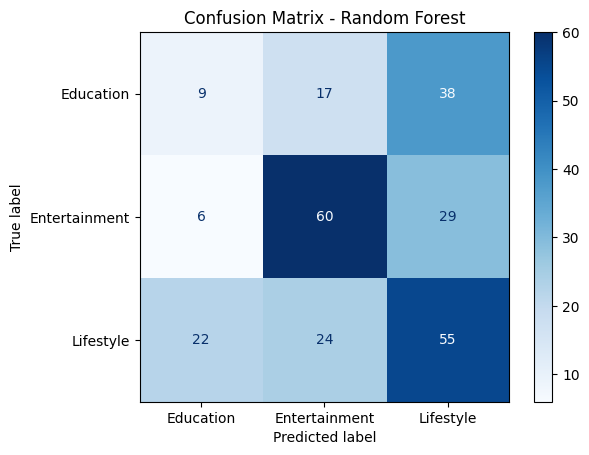

 Classification Report:
               precision    recall  f1-score   support

    Education       0.24      0.14      0.18        64
Entertainment       0.59      0.63      0.61        95
    Lifestyle       0.45      0.54      0.49       101

     accuracy                           0.48       260
    macro avg       0.43      0.44      0.43       260
 weighted avg       0.45      0.48      0.46       260


🔍 Training XGBoost...
 XGBoost Accuracy: 0.6154


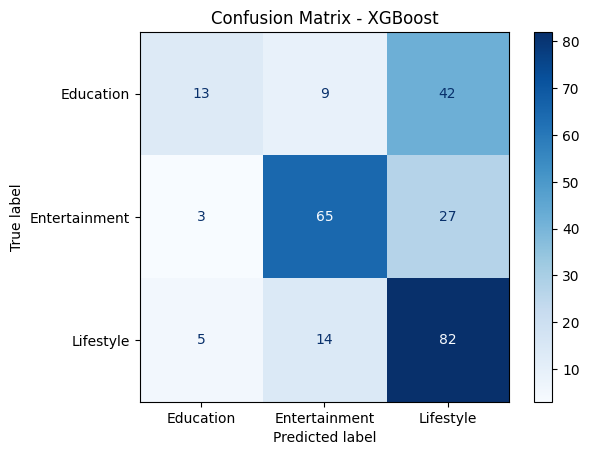

 Classification Report:
               precision    recall  f1-score   support

    Education       0.62      0.20      0.31        64
Entertainment       0.74      0.68      0.71        95
    Lifestyle       0.54      0.81      0.65       101

     accuracy                           0.62       260
    macro avg       0.63      0.57      0.56       260
 weighted avg       0.63      0.62      0.59       260



In [230]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

models = {
    "KNN": GridSearchCV(KNeighborsClassifier(), param_grid={"n_neighbors": [3, 5, 7]}, cv=3),
    "Decision Tree": GridSearchCV(DecisionTreeClassifier(class_weight="balanced"), param_grid={"max_depth": [3, 5, 10]}, cv=3),
    "Naive Bayes": GaussianNB(),
    "Random Forest": GridSearchCV(RandomForestClassifier(class_weight="balanced"), param_grid={"n_estimators": [50, 100]}, cv=3),
    "XGBoost": GridSearchCV(XGBClassifier(eval_metric='mlogloss', random_state=42),
        param_grid={"n_estimators": [50, 100], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.1]}, cv=3),
}

# ✨ Step 6: Train and evaluate
for name, model in models.items():
    print(f"\n🔍 Training {name}...")
    
    pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), model)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    #  Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f" {name} Accuracy: {accuracy:.4f}")

    #  Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_category.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    #  Classification Report (with string labels fix)
    target_names = [str(cls) for cls in le_category.classes_]
    print(" Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))


10 blocks because we have multiclass classifcation(10 categories in target colomn)

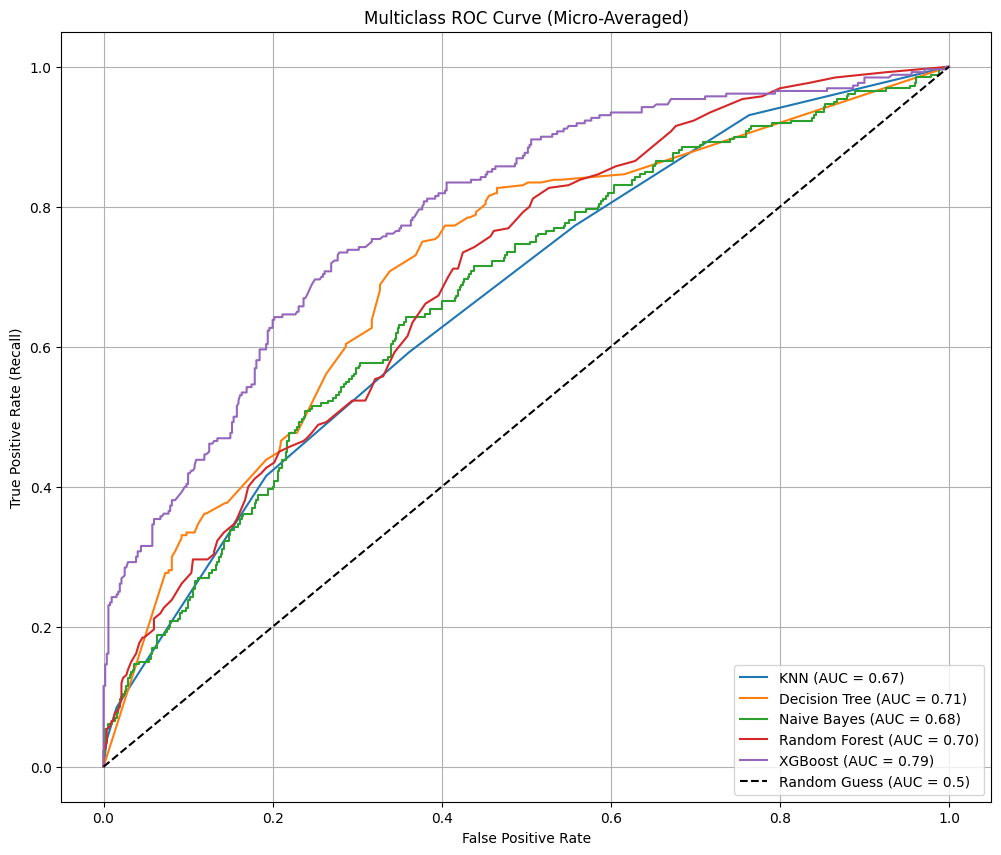

In [231]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import numpy as np

# Binarize the output for multiclass
y_test_bin = label_binarize(y_test, classes=list(range(3)))
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 10))

for name, model in models.items():
    # Imputation + model pipeline
    pipeline = make_pipeline(SimpleImputer(strategy='most_frequent'), model)
    pipeline.fit(X_train, y_train)

    # Get probabilities
    if hasattr(pipeline, "predict_proba"):
        y_probs = pipeline.predict_proba(X_test)
    else:
        try:
            y_probs = pipeline.decision_function(X_test)
        except:
            print(f"{name} does not support probability or decision_function.")
            continue

    # Compute micro-average ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Random Guess Line
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Multiclass ROC Curve (Micro-Averaged)")
plt.legend(loc="lower right")
plt.grid()
plt.show()


Metric	     Kya check karta hai?	     Kab use karein?
Accuracy	 Sahi jawab diye ya nahi	     Jab answers bilkul correct chahiyein
AUC	Model   guess kitna achha karta hai	 Jab model ke guess ka quality dekhna ho

In [235]:
# Real-time input from user
user_input = {
    'Views': 1000000,
    'Subscribers': 50000,
    'Country': 'US'
}

# Manual country-to-label mapping (based on how LabelEncoder encodes alphabetically)
label_map = {'AU': 0, 'CA': 1, 'IN': 2, 'PK': 3, 'US': 4}

# Encode the country using the manual mapping
user_input['Country'] = label_map[user_input['Country']]

# Convert to DataFrame
input_df = pd.DataFrame([user_input])

# Predict using the trained model
prediction = model.predict(input_df)[0]

# Display prediction result
if prediction == 0:
    print("Category:", "Lifestyle")
elif prediction == 1:
    print("Category:", "Entertainment")
else:
    print("Category:", "Education")

Category: Entertainment
